In [29]:
import numpy as np
import matplotlib.pyplot as plt
import sympy as sym
import scipy as sci
import pandas as pd
import soundfile as sf
from IPython.display import Audio, display

function Eksempel_L2c(f0)


N  = 12000;
fs = 12000;
%Benyt f0 = 3600, 5800, 6000, 7500, 12000, 11980, 15600

sample_count = [0:N-1];

sample_times0 = sample_count*(1/fs);


s0 = sin(f0*2*pi*sample_times0);
s0 = sin(f0*2*pi*sample_times0 + pi/2);  % v�sentligt ved f0=fs/2

figure(2); clf
stem(sample_times0(1:500), s0(1:500))  % 500, n�r f0=11980
xlabel('Tid i sekunder')


S0 = fft(s0, fs);

figure(3); clf
plot(20*log10(abs(S0)))
xlabel('Frekvens i Hertz')

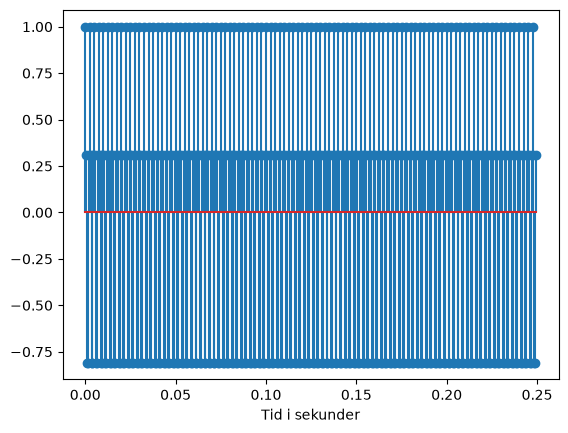

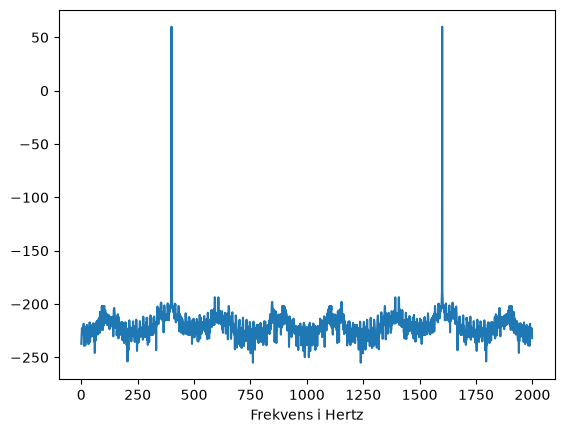

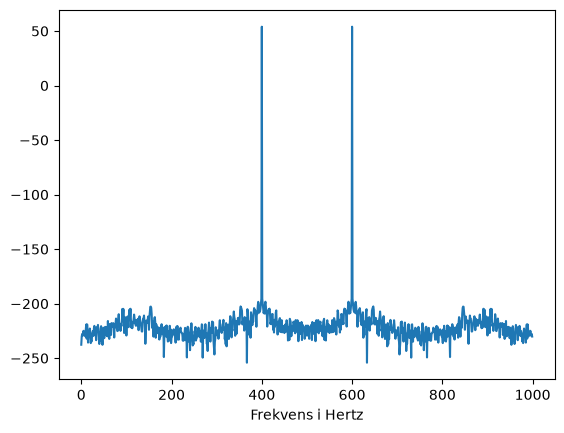

In [19]:

N = 12000
fs = 2000

# Try: 3600, 5800, 6000, 7500, 12000, 11980, 15600
f0 = 3600

sample_count = np.arange(N)
sample_times0 = sample_count * (1 / fs)

s0 = np.sin(f0 * 2 * np.pi * sample_times0)

# Important at f0 = fs/2
s0 = np.sin(f0 * 2 * np.pi * sample_times0 + np.pi / 2)

plt.figure(2)
plt.clf()
plt.stem(sample_times0[:500], s0[:500])

plt.xlabel("Tid i sekunder")
plt.show()

S0 = np.fft.fft(s0, fs)

plt.figure(3)
plt.clf()
plt.plot(20 * np.log10(np.abs(S0)))

plt.xlabel("Frekvens i Hertz")
plt.show()


fs = 1000

sample_times0 = sample_count * (1 / fs)

s0 = np.sin(f0 * 2 * np.pi * sample_times0 + np.pi / 2)

S0 = np.fft.fft(s0, fs)

plt.figure(4)
plt.clf()
plt.plot(20 * np.log10(np.abs(S0)))

plt.xlabel("Frekvens i Hertz")
plt.show()

1.11
Bestem Nyquist-frekvensen, når samplefrekvensen fs er 6kHz. To toner med frekvenserne henholdsvis 2,7
kHz og 3,8kHz samples med fs. Hvordan bliver de repræsenteret?


In [8]:
fs = 6000

f1 = 2700
f2 = 3800


f_nyquist = fs/2

f1_spejling =  2*f_nyquist - f1
f2_spejling =  2*f_nyquist - f2


print(f"der vil indenfor interfallet 0 til 6 KHz være 4 udsving: ved")
print(f1)
print(f2_spejling)
print(f2)
print(f1_spejling)

der vil indenfor interfallet 0 til 6 KHz være 4 udsving: ved
2700
2200.0
3800
3300.0


1.12
En sample-talfølge med Ts = 10ms viser en sinus med en frekvens på 68Hz. Kan vi være sikre på, at det
oprindelige analoge signal er en 68Hz sinus? Vis med et eksempel at det ikke er tilfældet.


sample frekvensen er kun 100.0 Hz
nyquist fekvensen er dermed  50.0 Hz
dermed vil signalet blive spejlet til 32.0 Hz


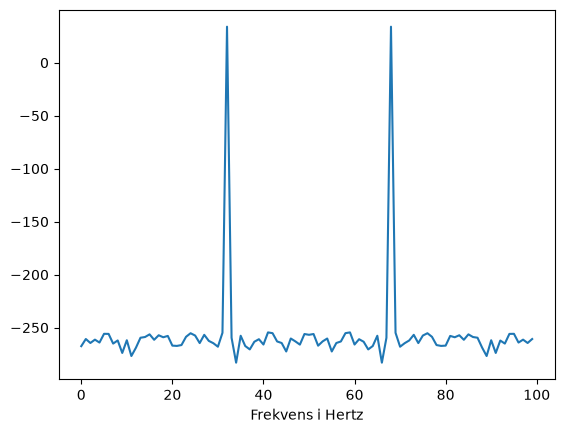

In [62]:
Ts = 0.010

f0 = 68

fs = 1/Ts
f_nyquist = fs/2

print(f"sample frekvensen er kun {fs} Hz")
print(f"nyquist fekvensen er dermed  {f_nyquist} Hz")

f0_spejling =  2*f_nyquist - f0

print(f"dermed vil signalet blive spejlet til {f0_spejling} Hz")


sample_count = np.arange(1000)

sample_times0 = sample_count * (1 / fs)

s0 = np.sin(f0 * 2 * np.pi * sample_times0 + np.pi / 2)

S0 = np.fft.fft(s0, int(fs))

plt.figure(4)
plt.clf()
plt.plot(20 * np.log10(np.abs(S0)))

plt.xlabel("Frekvens i Hertz")
plt.show()

1.13
Konstruer et undersamplet signal vha. nedsampling og vis grafisk at der er opstået problematisk aliasering.


sample frekvensen er kun 100.0 Hz
nyquist fekvensen er dermed  50.0 Hz
dermed vil signalet blive spejlet til 32.0 Hz


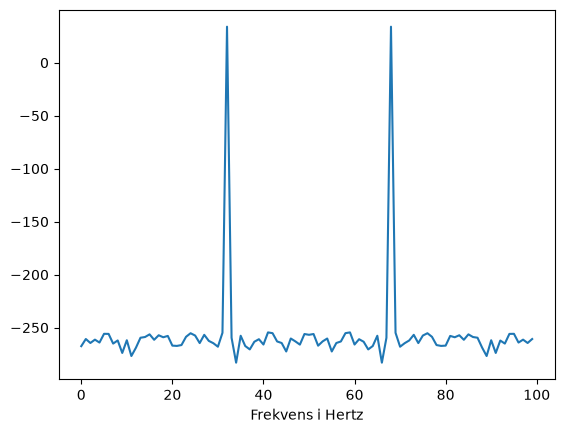

In [17]:
Ts = 0.010

f0 = 68

fs = 1/Ts
f_nyquist = fs/2

print(f"sample frekvensen er kun {fs} Hz")
print(f"nyquist fekvensen er dermed  {f_nyquist} Hz")

f0_spejling =  2*f_nyquist - f0

print(f"dermed vil signalet blive spejlet til {f0_spejling} Hz")


sample_count = np.arange(1000)

sample_times0 = sample_count * (1 / fs)

s0 = np.sin(f0 * 2 * np.pi * sample_times0 + np.pi / 2)

S0 = np.fft.fft(s0, int(fs))

plt.figure(4)
plt.clf()
plt.plot(20 * np.log10(np.abs(S0)))

plt.xlabel("Frekvens i Hertz")
plt.show()

1.14
Indlæs Music_sample_48kHz.wav og udtag venstre kanal. Lav nedsamplede versioner med funktionen
’resample’ eller ’decimate’ og lyt. Benyt nedsamplingsfaktorerne 2, 4, 8 og 16.


In [36]:
# Load WAV file
audio, fs = sf.read("./filer/Music_sample_48kHz.mp3")

# Extract left channel
left = audio[:, 0]

# Downsampling factors
factors = [2, 4, 8, 16]

for factor in factors:
    # Downsample
    downsampled = sci.signal.decimate(left, factor)

    #decimate  takes the downscaling factor
    #resample  takes the amount of points to sample to, effectifely the length


    # New sample rate
    new_fs = fs // factor

    print(f"Factor: {factor}, Sample rate: {new_fs} Hz")

    # Listen to result
    display(Audio(downsampled, rate=new_fs))

Factor: 2, Sample rate: 24000 Hz


Factor: 4, Sample rate: 12000 Hz


Factor: 8, Sample rate: 6000 Hz


Factor: 16, Sample rate: 3000 Hz


1.15
Lav en ”manuel” nedsampling på signalet fra opgave 1.14 med faktorerne M=8 og M=16. Sammenlign med
resultatet fra 1.14. Hvori består forskellen – og hvad er mon forklaringen?


In [50]:
downsample_8 = left[::8]

new_fs_8 = fs//8

print(f"Factor: {8}, Sample rate: {new_fs_8} Hz")
    
display(Audio(downsample_8, rate=new_fs_8))


display(Audio(left[::16], rate=fs//16))

Factor: 8, Sample rate: 6000 Hz


1.16
En 12 bit A/D konverter med +/- 8 volt indgang fodres med en analog sinus med amplitude på 4V. Hvad kan
forventes af SQNR for dette scenarie?

In [59]:
bit = 12
range = 8



in_range = 4

SQNR = 6.02*bit+1.76+20*np.log10(in_range/range)




print(f"{SQNR} db")


67.97940008672037 db
